## Pricing


European Option Pricing & Implied Volatility


In [ ]:
from options.option import Option
from pricing import BlackScholesPricer

opt = Option(S=100, K=100, T=1, r=0.05, sigma=0.3, opt_type='call')

price = BlackScholesPricer.price(opt)
print(f"Option Price: {price:.4f}")
iv = BlackScholesPricer.implied_volatility(price, opt)
print(f"Implied Volatility: {iv:.4f}")

print(f"Delta: {BlackScholesPricer.delta(opt):.4f}")
print(f"Gamma: {BlackScholesPricer.gamma(opt):.4f}")
print(f"Vega: {BlackScholesPricer.vega(opt):.4f}")
print(f"Theta: {BlackScholesPricer.theta(opt):.4f}")
print(f"Rho: {BlackScholesPricer.rho(opt):.4f}")


Option Price: 14.2313
Implied Volatility: 0.3000
Delta: 0.6243
Gamma: 0.0126
Vega: 37.9433
Theta: -8.1012
Rho: 48.1939


Asian Option Pricing w/ Monte Carlo


In [ ]:
from options.option import Option
from pricing import MonteCarloPricer

S = 100
K = 100 
T = 1
r = 0.05
sigma = 0.3 
option = Option(S=S, K=K, T=T, r=r, sigma=sigma, opt_type='call')
# 10,000 paths, 252 steps
euro_price = MonteCarloPricer.price_european(option)
print(f"European Option Price: {euro_price:.4f}")

asian_price = MonteCarloPricer.price_asian(option)
print(f"Asian Option Price: {asian_price:.4f}")

European Option Price: 14.0780
Asian Option Price: 7.9836


American Option Pricing w/ Binomial Trees


In [ ]:
from pricing import BinomialTreePricer
from options.option import Option

S0 = 100
K = 100 
T = 1
r = 0.05
u = 1.1 
d = 1/u
option = Option(S=S0, K=K, T=T, r=r, sigma=0.3, opt_type='call')
american_price = BinomialTreePricer.price_american(option, u=u, d=d, n_steps=100)
print(f"American Option Price: {american_price:.4f}")

American Option Price: 38.1336


Heston Model Pricing


In [ ]:
from options.option import Option
from pricing import HestonModel
import numpy as np

opt = Option(S=110, K=100, T=1, r=0.05, sigma=0.2, opt_type='call')
price = HestonModel.price(opt, kappa=1.0, theta=0.04, sigma=0.3, rho=-0.7, v0=0.04)
print(price)

18.13637971267737


### Implied Volatility

In [3]:
from options import Option
from options import ImpliedVolatility
from pricing import BlackScholesPricer
from pricing import MonteCarloPricer
from pricing import HestonModel
from pricing import BinomialTreePricer

option = Option(
    S=100,
    K=100,
    T=1,
    r=0.05,
    sigma=0.20
)

market_price = 15

# --- Black-Scholes (deterministic, no seed needed) ---
iv_bs = ImpliedVolatility.solve(
    option, market_price,
    pricer=BlackScholesPricer.price
)

# --- Binomial tree / American (deterministic) ---
iv_tree = ImpliedVolatility.solve(
    option, market_price,
    pricer=lambda opt: BinomialTreePricer.price_american(opt, u=1.01, d=0.99)
)

# --- Monte Carlo (stochastic -> pass a seed) ---
iv_mc = ImpliedVolatility.solve(
    option, market_price,
    pricer=lambda opt: MonteCarloPricer.price_european(opt, n_paths=20000),
    seed=42
)

# --- Heston (stochastic -> pass a seed) ---
iv_heston = ImpliedVolatility.solve(
    option, market_price,
    pricer=lambda opt: HestonModel.price(opt, kappa=2, theta=0.04, sigma=0.3,
                                          rho=-0.7, v0=0.04, n_paths=20000),
    seed=42
)
print(iv_bs, iv_tree, iv_mc, iv_heston)


0.32025830955048273 nan 0.328447607231289 nan


## Processes


Geometric Brownian Motion


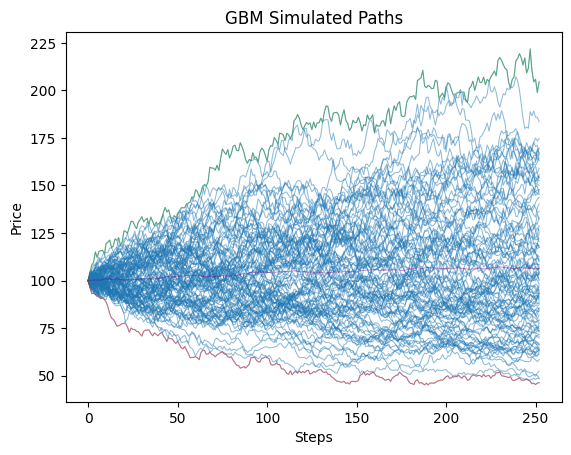

In [3]:
from processes.gbm import GeometricBrownianMotion
S = 100 
mu = 0.08
sigma = 0.3 
T = 1
dt = 1/252
n = 100
gbm = GeometricBrownianMotion(S0=S, mu=mu, sigma=sigma) 
paths = gbm.sim_paths(T=T, dt=dt, n_paths=n)
gbm.plot_paths(paths=paths)

Arithmetic Brownian Motion

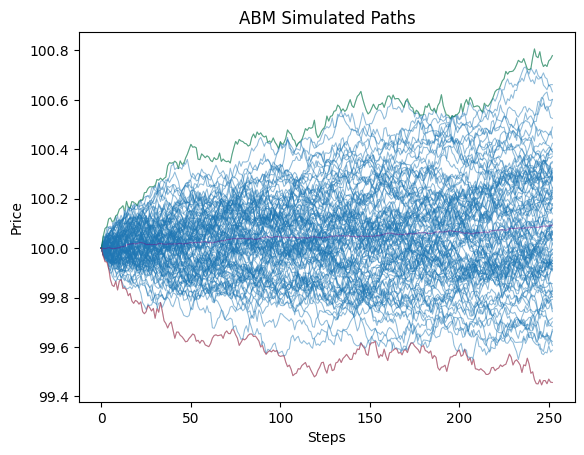

In [13]:
from processes import ArithmeticBrownianMotion

S = 100 
mu = 0.08
sigma = 0.3 
T = 1
dt = 1/252
n = 100
abm = ArithmeticBrownianMotion(S0=S, mu=mu, sigma=sigma)
paths = abm.sim_paths(dt=dt, T=T, n_paths=n)
abm.plot_paths(paths=paths)

Vasicek Model


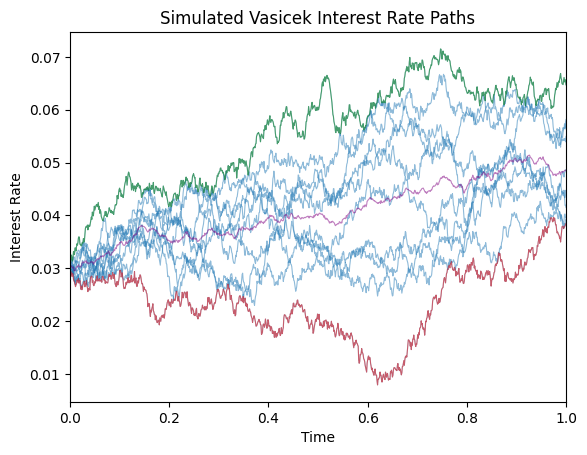

In [ ]:
from processes.vasicek import VasicekProcess

theta = 2.0  # Speed of mean reversion
mu = 0.05  # Long-term mean interest rate (5%)
sigma = 0.02  # Volatility of the random component (2%)
r0 = 0.03  # Initial value of the interest rate (3%)
T = 1.0  # Time horizon (1 year)
dt = 0.001  # Time step size
num_simulations = 100  # Number of sample paths to generate

vasicek = VasicekProcess(theta=theta, mu=mu, sigma=sigma, r0=r0, T=T, dt=dt)
df = vasicek.mc_sim(10)
vasicek.plot_paths(df)


Ornstein Uhlenbeck Process


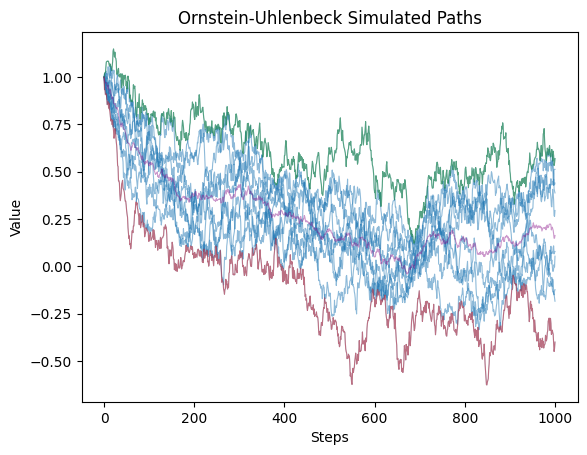

In [ ]:
from processes.ou import OrnsteinUhlenbeck

theta = 0.7      # Speed of mean reversion
mu = 0.08        # Long-term mean
sigma = 0.3      # Volatility
X0 = 1.0         # Initial value
T = 10.0         # Total time
dt = 0.01        # Time step
n = 10
oh = OrnsteinUhlenbeck(X0=X0, theta=theta, mu=mu, sigma=sigma, T=T, dt=dt)
X = oh.process(n_paths=n)

oh.plot_paths(X)


Jump Diffusion Model


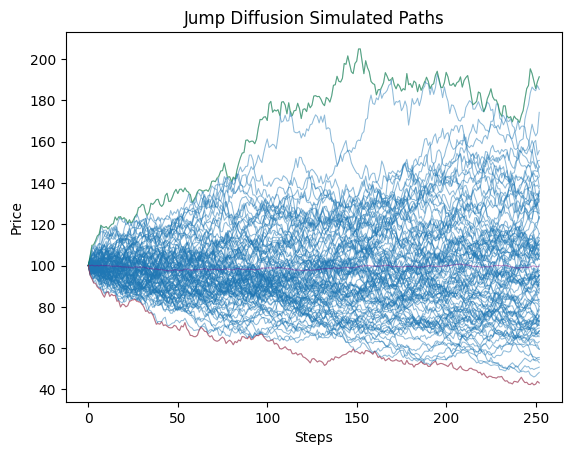

In [2]:
from processes import JumpDiffusion
S = 100 
mu = 0.08
sigma = 0.3 
T = 1
dt = 1/252
n = 100
lambda_j = 0.1
mu_j = 0.1
sigma_j = 1.e-6
jd = JumpDiffusion(S0=S, mu=mu, sigma=sigma, lambda_j=lambda_j, mu_j=mu_j, sigma_j=sigma_j) 
paths = jd.sim_paths(T=T, dt=dt, n_paths=n)
jd.plot_paths(paths=paths)

Portfolio Metrics


In [1]:
import yfinance as yf
from portfolio.metrics import PortfolioMetrics

prices = yf.download("SPY", start="2020-01-01", end="2023-01-01")['Close']
returns = prices.pct_change().dropna()

metrics = PortfolioMetrics(returns, risk_free_rate=0.05)

print(f"Annual Return: {metrics.annualized_return():.4f}")
print(f"Annualized Volatility: {metrics.annualized_volatility():.4f}")
print(f"Sharpe Ratio: {metrics.sharpe_ratio():.4f}")
print(f"Max Drawdown: {metrics.max_drawdown():.4f}")
print(f"Calmar Ratio: {metrics.calmar_ratio():.4f}")
print(f"Sortino Ratio: {metrics.sortino_ratio():.4f}")



[*********************100%***********************]  1 of 1 completed

Annual Return: 0.1018
Annualized Volatility: 0.2499
Sharpe Ratio: 0.2074
Max Drawdown: -0.3372
Calmar Ratio: 0.3020
Sortino Ratio: 0.1955


In [ ]:
from options.option import Option
from pricing import BlackScholesPricer

opt = Option(S=100, K=100, T=1, r=0.05, sigma=0.3, opt_type='call')

price = BlackScholesPricer.price(opt)
print(f"Option Price: {price:.4f}")
iv = BlackScholesPricer.implied_volatility(price, opt)
print(f"Implied Volatility: {iv:.4f}")

print(f"Delta: {BlackScholesPricer.delta(opt):.4f}")
print(f"Gamma: {BlackScholesPricer.gamma(opt):.4f}")
print(f"Vega: {BlackScholesPricer.vega(opt):.4f}")
print(f"Theta: {BlackScholesPricer.theta(opt):.4f}")
print(f"Rho: {BlackScholesPricer.rho(opt):.4f}")


Option Price: 14.2313
Implied Volatility: 0.3000
Delta: 0.6243
Gamma: 0.0126
Vega: 37.9433
Theta: -8.1012
Rho: 48.1939
